<a href="https://colab.research.google.com/github/val-ium/data-analytics/blob/main/Capstone_like_Val.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the dataframe


In [1]:
import pandas as pd

In [2]:
URL = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

In [3]:
df = pd.read_csv(URL)

### Set the index to the base_date_time.

In [4]:
df["base_date_time"] = pd.to_datetime(df['base_date_time'])

In [5]:
df.dtypes

,0
mmsi,int64
base_date_time,datetime64[ns]
longitude,float64
latitude,float64
sog,float64
cog,float64
heading,float64
vessel_name,object
imo,object
call_sign,object


In [6]:
df = df.set_index('base_date_time')

### Clean the data: we don't want any row where the sog is null

In [7]:
df = df.dropna(subset = ["sog"])
df.isnull().sum()

,0
mmsi,0
longitude,0
latitude,0
sog,0
cog,1057382
heading,2996089
vessel_name,17112
imo,3555229
call_sign,730004
vessel_type,42176


###First Analysis: When are boats out?


####Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel.

In [ ]:
#convert df to an hourly measurement
df_per_hour = df.groupby(df.index.hour)

#count the unique boats per hour
boats_per_hour = df_per_hour['mmsi'].nunique()


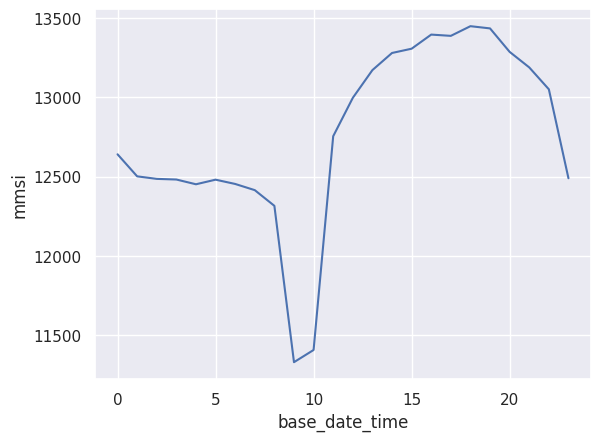

In [15]:
import seaborn as sns

sns.set_theme()

hourly_chart = sns.lineplot (boats_per_hour)

####What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?

In [23]:
#Hour with the most/least amount of boats
print(boats_per_hour.idxmax())
print(boats_per_hour.idxmin())

18
9


In [ ]:
"""
It looks like the least amount of boats were out at 9:00 UTC. I am assuming this data was collected
from american ships so this makes sense as it would be from 3:00 AM EST. The same logic applies for the most boats on the water since the
measurement is taken at 1 pm EST.

"""



###Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day.

####Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)

In [27]:
#Finding Henry Hudson

henry = df[df['mmsi']== 366651000 ].sort_index()

In [31]:
henry['acceleration'] = henry['sog'].diff()

####Create a duration column, which is the difference between each "base_date_time"

In [34]:
#index must be converted to series in order for .diff to work
henry['duration'] = henry.index.to_series().diff()

#### Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.

In [36]:
henry_on = henry[henry['acceleration'] > 0]

####Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain

In [37]:
henry_on_total = henry_on['duration'].sum()

In [38]:
henry_on_total

Timedelta('0 days 08:03:24')

In [ ]:
# The boat engines were on for 8 hours 3 minutes and 24 seconds that day.

### create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.

In [42]:
def calculate_total_active_engine_time (mmsi):

  boat = df[df['mmsi'] == mmsi].sort_index()

  boat['acceleration'] = boat['sog'].diff()
  boat['duration'] = boat.index.to_series().diff()

  boat_on = boat[boat['acceleration'] > 0]

  boat_on_total = boat_on['duration'].sum()

  return boat_on_total
